Hedgers
```
BRIAN WEE JOON LI
HU ZIHAO
JI NIAN
YAN TONGSHU
ZHOU XUAN
```
---



# Notebook 9 - Recurrent neural networks

This is a graded group assignment. After you are done, please share the link to your assignment with Fedor for grading.

Note that you are allowed to use google in this assignment. In particular, there are some questions that require justified answers and it will be good if you can support your answer with relevant links.

In [ ]:
import time

import pandas as pd
import numpy as np
from numpy.random import seed

import plotly.express as px
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers import LSTM
from keras.layers import Embedding
from keras import regularizers

from keras.datasets import reuters

To avoid unnecessary complications with loading data into Python, we will work a dataset available in `tensorflow`.

The data is a collection of Reuters news articles, already pre-processed. The problem is multi-task classification - we need to train a model that will predict which class a news article belongs to. There are 46 classes, but there are no labels - just numbers. If you figure out class names, you will get a higher score for this assignment (there are other opportunities to get a higher score).

We will train a recurrent neural network to predict the label given an article's text. Same type of recurrent neural networks can be used for trading - to predict some stock index given a recent history of several stock indices.

Let's get going.

Here we load the data to Python

In [ ]:
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=None, test_split=0.2)
word_index = reuters.get_word_index(path="reuters_word_index.json")

print('No of training samples: {}'.format(len(x_train)))
print('No of test samples: {}'.format(len(x_test)))

num_classes = max(y_train) + 1
print('No of classes: {}'.format(num_classes))

vocab_size = max([max(a) for a in x_train])
print('No of words in the vocabulary:', vocab_size)
article_lengths = [len(a) for a in x_train]
longest_length = max(article_lengths)
print('Mean No of words in an article:', np.mean(article_lengths))
print('No of words in the longest training article:', longest_length)

print('No of words in the first 5 articles:')
print([len(a) for a in x_train[:5]])

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
No of training samples: 8982
No of test samples: 2246
No of classes: 46
No of words in the vocabulary: 30981
Mean No of words in an article: 145.5398574927633
No of words in the longest training article: 2376
No of words in the first 5 articles:
[87, 56, 139, 224, 101]


The dataset has been pre-processed. Below is a training example as it is stored in the training dataset and translated into more-or-less readable text (Fedor couldn't figure out how it was processed).

In [ ]:
import pprint

index_to_word = {}
for key, value in word_index.items():
    index_to_word[value] = key

def print_training_example(k, X = x_train, Y = y_train):
    print("Cleaned text:")
    pprint.pprint(' '.join([index_to_word[x] for x in X[k]]))
    print("The dataset actually contains:")
    pprint.pprint(np.array(X[k]))
    print("Response =", Y[k])
    return None

print_training_example(50)


Cleaned text:
('the positions africa profit mln at positions africa western profit most bill '
 "10 3 commodities tough assumed 761 tonnes said shell's profit oper 10 7 in "
 'imported said trade billion is said in recent oper 10 income a for increases '
 "was in since 3 co minister positions africa western mln 1 japan's 9 inc vs "
 "000 and shell's that development owned and nations targets mortgages tonnes "
 "said shell's holds shareholder drilling index 10 in index 10 cts drilling "
 "common holiday physical shell's oper tonnes 3 commodities and based "
 "producers holiday physical tonnes positions africa 3 at company's mln in "
 "shell's 10 cts previously loss not due shr stock he stores 3 carefully its "
 'pay and pay pct dlrs')
The dataset actually contains:
array([   1, 1479, 1197,   71,    8,   25, 1479, 1197,  640,   71,  304,
        471,   80,    9, 1379, 1901, 4530, 6797,   79,    5, 8144,   71,
        175,   80,   58,    4, 1279,    5,   63,   32,   20,    5,    4,
     

Here is a word cloud for the same training example:

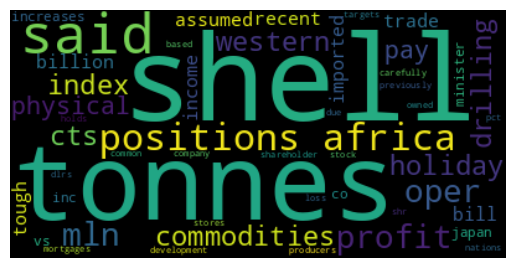

In [ ]:
F = ' '.join([index_to_word[x] for x in x_train[50]])

wordcloud = WordCloud().generate(F)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

To train a recurrent neural network, we need to _pad_ all our word sequences . It means that we will just insert zeroes in front of each sequence to make their length equal.

Here is how padding works:

In [ ]:
sequence = [[1], [2, 3], [4, 5, 6]]
print("Raw sequence is:")
print(sequence)
print("Padded sequence is:")
print(tf.keras.preprocessing.sequence.pad_sequences(sequence))

Raw sequence is:
[[1], [2, 3], [4, 5, 6]]
Padded sequence is:
[[0 0 1]
 [0 2 3]
 [4 5 6]]


Now we will pad our data. Here, we will also do an extra - we will pad our sequences to a certain length and trim those that are longer. This is needed to speed up the training (longer sequences will result in longer time to train our recurrent neural network)

In [ ]:
max_length = 200
x_train_pad = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen = max_length)
x_test_pad = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen = max_length)
print("dim (padded sequences) =", x_train_pad.shape)

dim (padded sequences) = (8982, 200)


The last step in data pre-processing is to one-hot encode values of the response variable (it is a categorical variable wih 46 classes).

In [ ]:
y_train_multi = keras.utils.to_categorical(y_train, num_classes)
y_test_multi = keras.utils.to_categorical(y_test, num_classes)

print("Sample of y_train we will use in the actual model training:")
print(y_train_multi[:3, :8])
print("dim(Y train) =", y_train_multi.shape)
print("dim(Y test) =", y_test_multi.shape)

Sample of y_train we will use in the actual model training:
[[0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]]
dim(Y train) = (8982, 46)
dim(Y test) = (2246, 46)


One last thing to understand about recurrent neural networks for text classification is that the first thing that our model should do is to convert sequences of numbers that encode words to sequences of vectors. In other words, our model needs to construct its own word embeddings similar to GloVe. To do it, we will add a special first layer called "embedding layer".

_Remark_: if we used recurrent neural networks for some other type of sequential data, we probably wouldn't need an embedding layer. For example, if we needed to predict the price of some stock exchange index using the history of several other indices, then our input data would just be a sequence of vectors and we wouldn't need an embedding layer (we still would need to pre-process the data).

We will create a simple model with 50-dimensional embeddings and an LSTM layer with 20 units. Feel free to change these numbers to smaller ones if this takes too much time on your computer to run (takes 204 seconds on Fedor's MacBook Pro with M1 chip).

Here we define our model

In [ ]:
### For reproducibility:

seed(42)
tf.random.set_seed(496)

# Define the model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=50, input_length=max_length))  # Include input_dim explicitly
model.add(LSTM(20, return_sequences=False))
model.add(Dense(num_classes, activation='linear'))

# Compile the model
model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['accuracy'])

# Ensure the model is built
model.build(input_shape=(None, max_length))

# Summarize the model
print(model.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 50)             │       1,549,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 20)                  │           5,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 46)                  │             966 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,555,696 (5.93 MB)

 Trainable params: 1,555,696 (5.93 MB)

 Non-trainable params: 0 (0.00 B)

None


And now we will train it. Note that it takes considerable time to train a recurrent neural network even on a small dataset:

In [ ]:
num_epochs = 5

start = time.time()

history = model.fit(x_train_pad, y_train_multi, \
                    validation_data=(x_test_pad, y_test_multi), \
                    epochs = num_epochs, verbose=1)

end = time.time()
print("Training the model took", np.round(end - start), "s")

score = model.evaluate(x_test_pad, y_test_multi)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.1623 - loss: 0.0233 - val_accuracy: 0.3402 - val_loss: 0.0220
Epoch 2/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3640 - loss: 0.0214 - val_accuracy: 0.4688 - val_loss: 0.0166
Epoch 3/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.3850 - loss: 0.0164 - val_accuracy: 0.3789 - val_loss: 0.0158
Epoch 4/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3884 - loss: 0.0157 - val_accuracy: 0.3989 - val_loss: 0.0158
Epoch 5/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3890 - loss: 0.0155 - val_accuracy: 0.3633 - val_loss: 0.0157
Training the model took 29.0 s
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3708 - loss: 0.0156
Test loss: 0.015703782439231873
Test accuracy: 0.3633125424385071


In [ ]:
def plot_train_history(hist):
    train_history = pd.DataFrame(hist.history)
    train_history["epoch"] = np.arange(num_epochs) + 1
    fig = px.line(train_history, x = 'epoch', y = ['accuracy', 'val_accuracy'])
    return fig

plot_train_history(history).show()

# Your work

Please insert your codes and your explanations below - they will be graded.

## Question 1

Plot a histogram of the number of words in news articles.

***ANS:***

In [ ]:
## Write your code here
## Write your code here
# Create the histogram
fig = px.histogram(x=article_lengths, nbins=250, labels={'x': 'Number of Words', 'y': 'Number of Articles'},
                   title='Histogram of Article Lengths', opacity=0.7)

# Show the plot
fig.show()


## Question 2

Plot the word cloud of all the texts in class "4". You will get a higher score if you do it without nested loops.

_Bonus question:_ can you plot such word clouds for all 46 classes on one diagram? They should be arranged on a $7\times 7$ grid?

_Another bonus question:_ can you figure out what are the 46 classes? You are allowed to use google.

***ANS:***

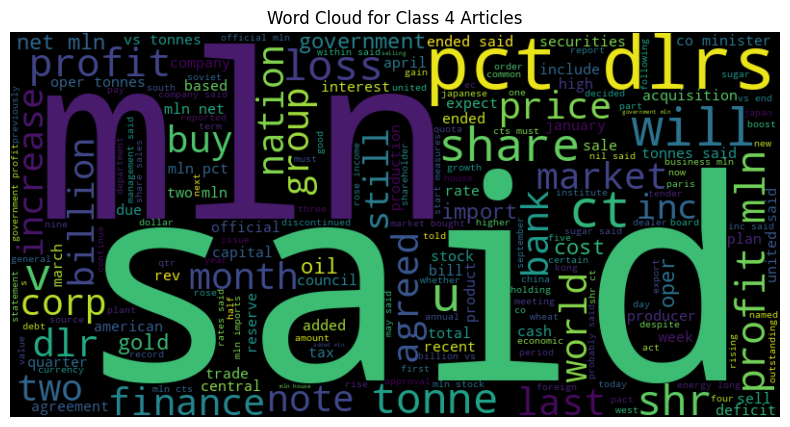

In [ ]:
## Write your code here

# Extract all articles in class 4
class_4_indices = np.where(y_train == 4)[0]
class_4_texts = np.concatenate([x_train[i] for i in class_4_indices])  # Flatten without nested loops

words = [index_to_word.get(word_id,'') for word_id in class_4_texts]

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(' '.join(words))

# Plot word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Class 4 Articles")
plt.show()


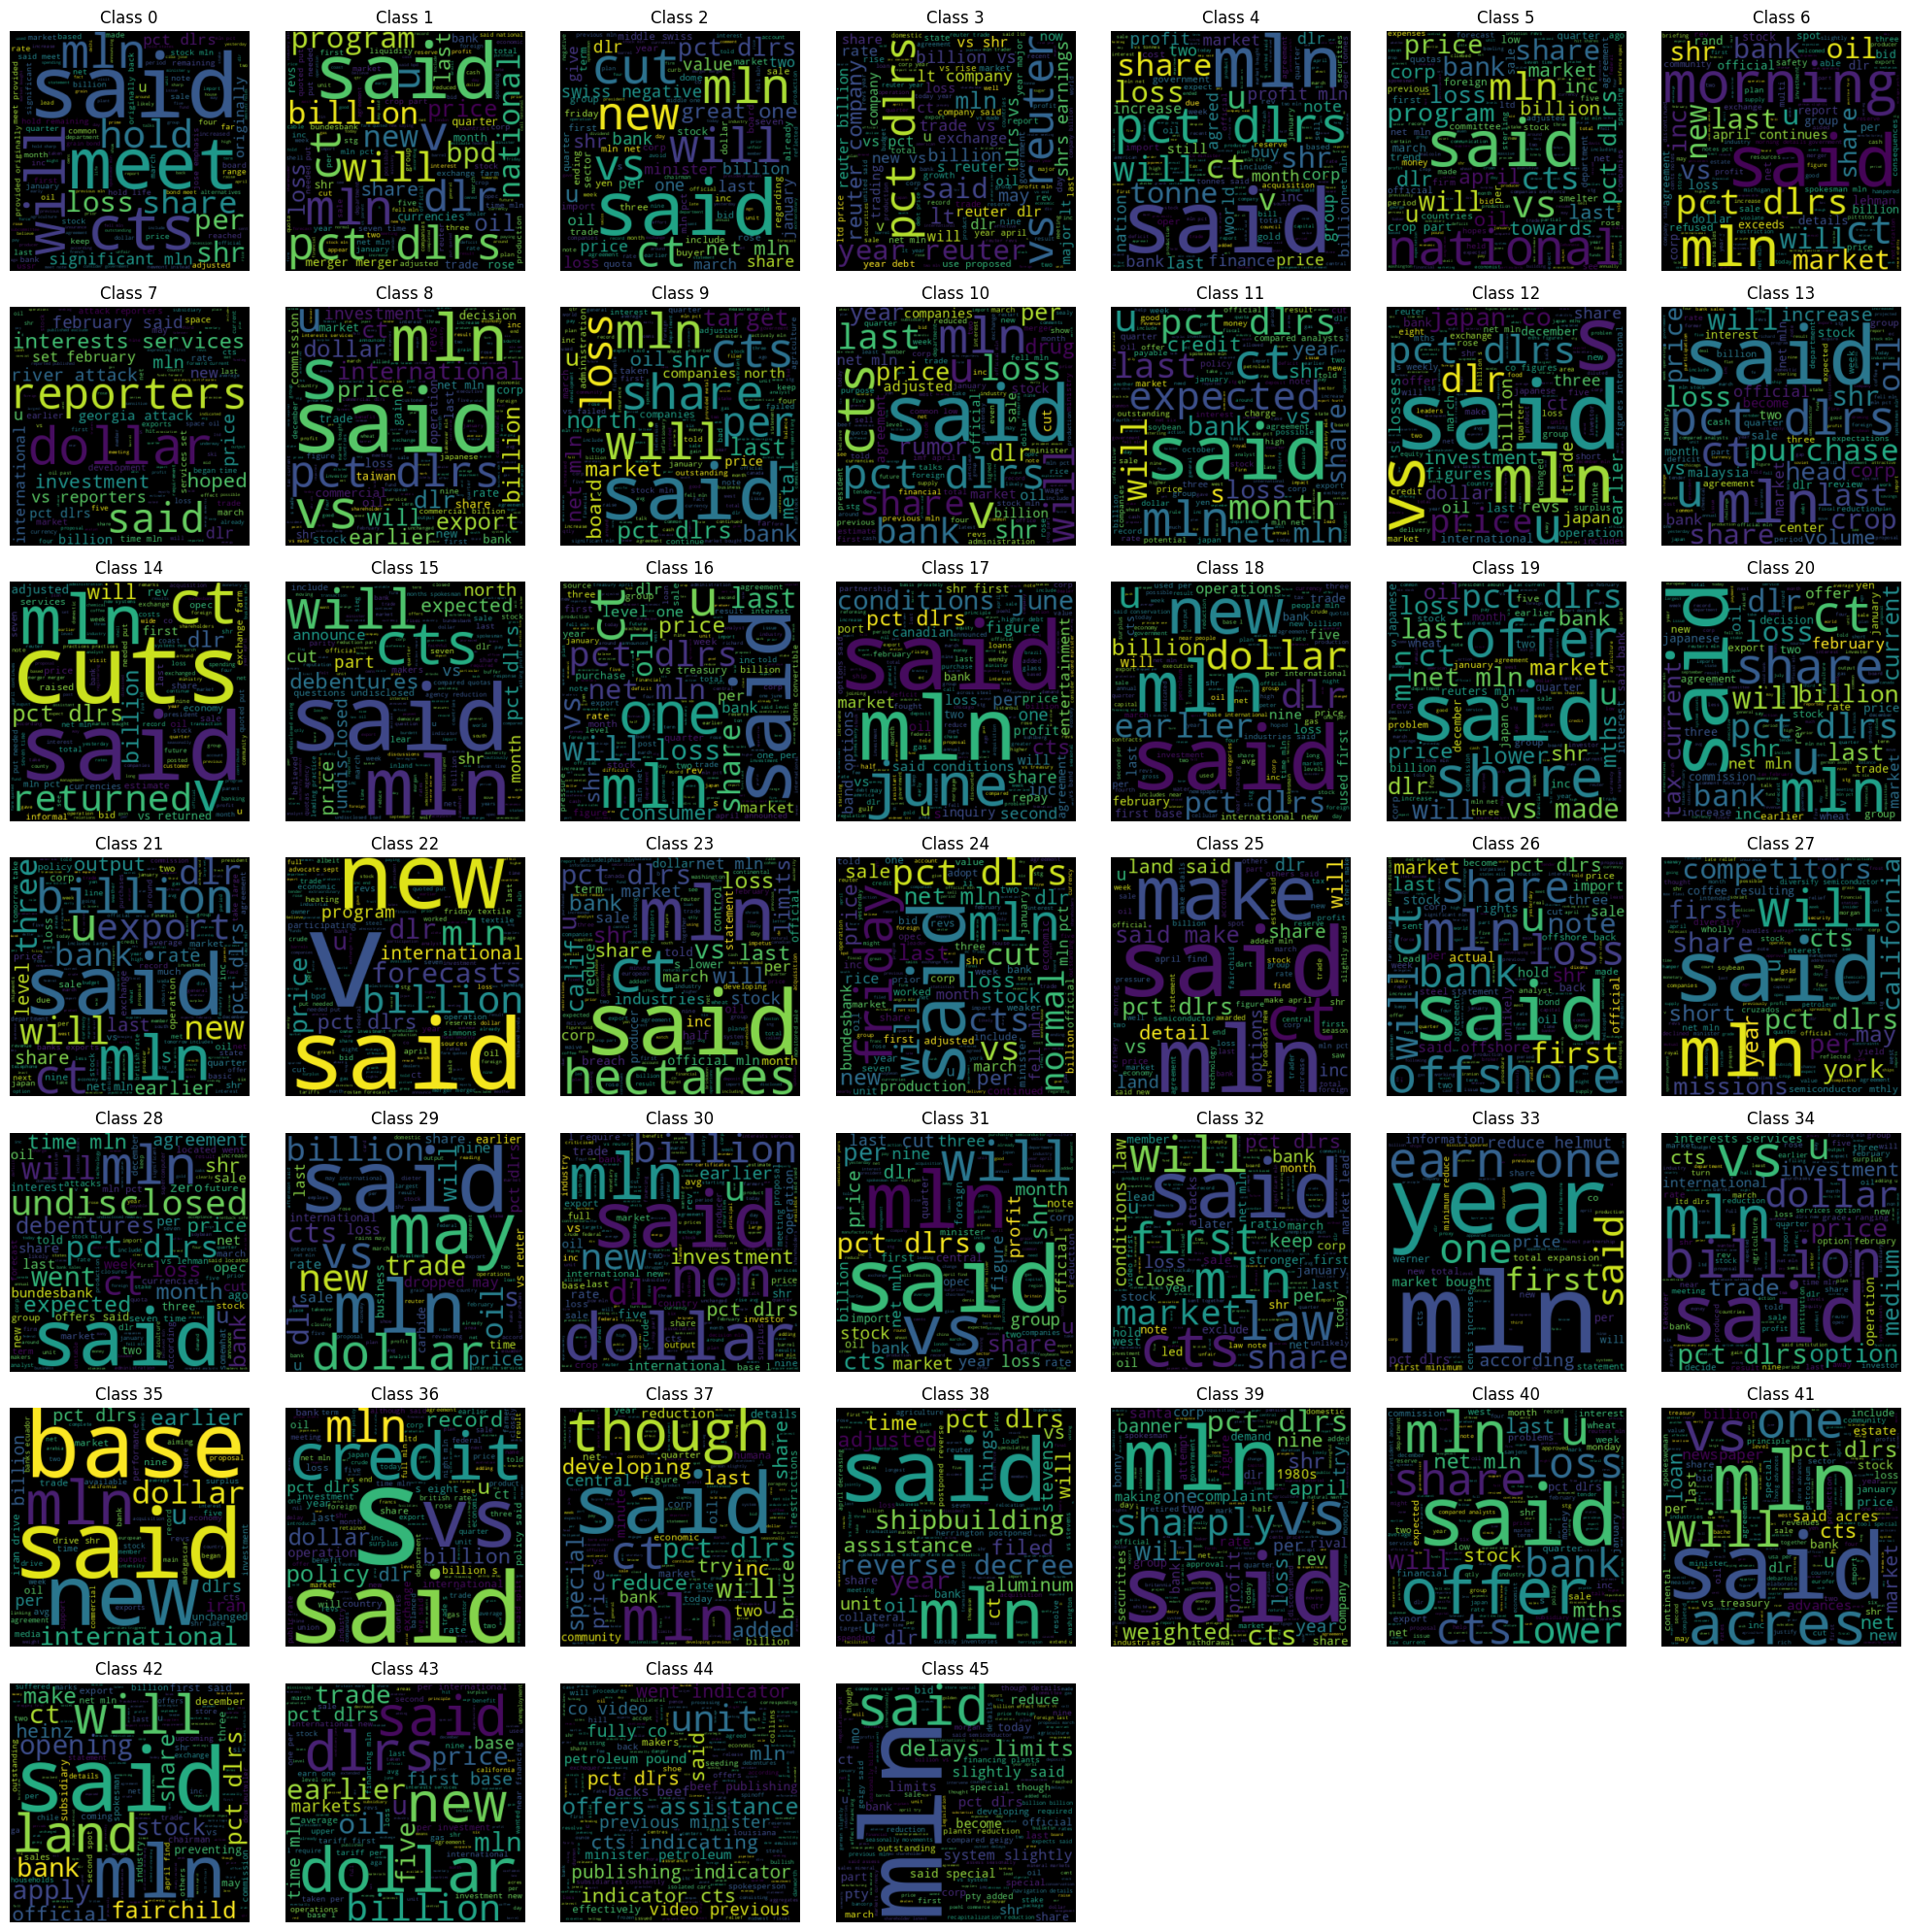

In [ ]:
fig, axes = plt.subplots(7, 7, figsize=(20, 20))

for class_label in range(46):
    ax = axes[class_label // 7, class_label % 7]

    # Extract words for the class
    class_indices = np.where(y_train == class_label)[0]
    class_texts = np.concatenate([x_train[i] for i in class_indices])
    words = [index_to_word.get(word_id, '') for word_id in class_texts]

    # Generate word cloud
    wordcloud = WordCloud(width=300, height=300, background_color='black').generate(' '.join(words))

    # Plot
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f"Class {class_label}")
    ax.axis("off")

# Hide any unused subplots (for slots > 46)
for i in range(46, 49):  # 49 = 7x7
    fig.delaxes(axes[i // 7, i % 7])

plt.tight_layout()
plt.show()

According to [Stephen Bauer's GitHub repo](https://github.com/SteffenBauer/KerasTools/tree/master/Reuters_Analysis), 46 classes are:<br>

```
['cocoa','grain','veg-oil','earn','acq','wheat','copper','housing','money-supply',
 'coffee','sugar','trade','reserves','ship','cotton','carcass','crude','nat-gas',
 'cpi','money-fx','interest','gnp','meal-feed','alum','oilseed','gold','tin',
 'strategic-metal','livestock','retail','ipi','iron-steel','rubber','heat','jobs',
 'lei','bop','zinc','orange','pet-chem','dlr','gas','silver','wpi','hog','lead']
```



## Question 3

The construction and the training of the recurrent neural model Fedor trained above has some serious errors. Besides, the model was not regularized. Define a correct new model, regularize it, train, report test accuracy, and plot the history of training.

Answer the following question: based on your plot, does your model overfit, underfit, or fits just right?

_Remark:_ we don't have time in class to properly fine-tune the model, especially since it takes considerable time to retrain it. You just need to know how to write the Python code correctly and get some rough idea of model diagnostics based on a plot of its training history.

***ANS:***

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning:

Argument `input_length` is deprecated. Just remove it.



281/281 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.3604 - loss: 2.9798 - val_accuracy: 0.5076 - val_loss: 2.0867
Epoch 2/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5110 - loss: 2.0236 - val_accuracy: 0.4800 - val_loss: 2.1814
Epoch 3/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5192 - loss: 1.9255 - val_accuracy: 0.5227 - val_loss: 1.8290
Epoch 4/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5562 - loss: 1.7088 - val_accuracy: 0.5601 - val_loss: 1.7384
Epoch 5/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5825 - loss: 1.6438 - val_accuracy: 0.5459 - val_loss: 1.7921
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5546 - loss: 1.7448
Test Accuracy: 0.5459


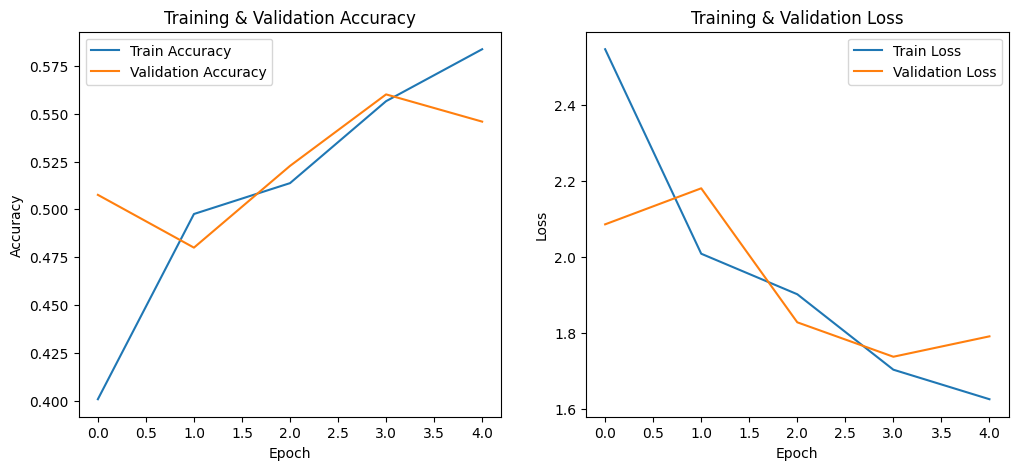

In [ ]:
### Write your code here

seed(42)
tf.random.set_seed(496)

# Define model parameters
embedding_dim = 50
lstm_units = 20
dropout_rate = 0.2
l2_lambda = 0.001  # L2 regularization


# Define regularized model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
   LSTM(lstm_units, return_sequences=False, kernel_regularizer=regularizers.l2(l2_lambda)),
    # LSTM(lstm_units, return_sequences=False),

    Dropout(dropout_rate),  # Dropout for regularization
    Dense(num_classes, activation='softmax')  # Softmax for multi-class classification
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x_train_pad, y_train_multi, epochs=num_epochs, batch_size=32, validation_data=(x_test_pad, y_test_multi), verbose=1)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(x_test_pad, y_test_multi)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.show()


***It seems that the model trained is underfitting as there is no clear sign of convergence of the train accuracy curve. More epochs should be used which is illustrated in Q4.***

## Question 4

Suggest strategies for how to make the model more accurate in practice. If you have more time and resources to train the model, what would you do?

One of possible approaches is to train a model with more than one LSTM layer. You will get a higher score if you write a working Python code for doing it.

***ANS:***
1. Train for More Epochs<br>
The model might not have trained long enough as the accuracy curves did not converge. The number of epochs adopted could be raised to 10-50 while monitoring validation loss.<br>

2. Use a Larger Embedding Dimension<br>
The embedding layer maps words into a dense vector space. Using embedding_dim = 100 or 200 (instead of 50) might improve representation.

3. Increase Model Complexity<br>
Current LSTM model might not be expressive enough. <br>
More LSTM units: Increase from 50 to a larger value (e.g. 64).<br>
Stacking multiple LSTM layers: Add another LSTM layer before the dense layer.<br>
Bidirectional LSTM: Helps capture dependencies in both directions.<br>

4. Hyperparameters Tuning<br>
Besides the number of lstm units and embedding dimension, the other hyperparameters include the optimizer(e.g. SGD adam with momentum), batch_size(usually power of 2), number of epochs, learning rate, regularizaiton params (lambda and dropout probability) and etc. Even the seed could be considered as hyperparams sometimes [Torch.manual_seed(3407) is all you need: On the influence of random seeds in deep learning architectures for computer vision
](https://arxiv.org/abs/2109.08203) Finetuning these hyperparameters will definitely improve the model's performance.<br>

***Due to time being, only points 1 and 3 were implemented.***

Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.3777 - loss: 2.6953 - val_accuracy: 0.5022 - val_loss: 1.9317
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.5214 - loss: 1.8441 - val_accuracy: 0.5530 - val_loss: 1.7666
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5410 - loss: 1.7490 - val_accuracy: 0.5543 - val_loss: 1.7728
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5739 - loss: 1.6575 - val_accuracy: 0.5539 - val_loss: 1.7635
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6032 - loss: 1.5628 - val_accuracy: 0.5797 - val_loss: 1.6631
Epoch 6/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6415 - loss: 1.4409 - val_accuracy: 0.5948 - val_loss: 1.6128
Epoch 7/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6581 - loss: 1.3567 - val_accuracy: 0.6042 - val_loss: 1.5841
Epoch 8/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.6944 - loss: 1.2172 - val_a

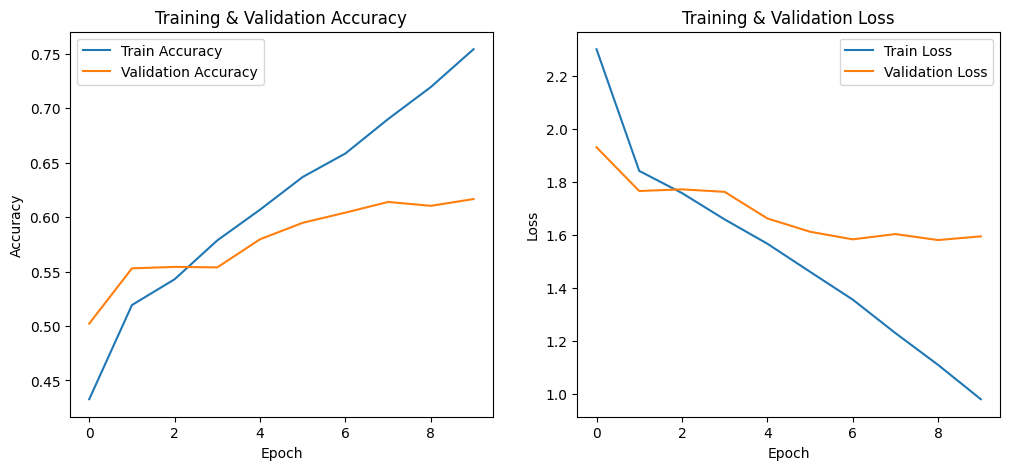

In [ ]:
# Define model parameters
seed(42)
tf.random.set_seed(496)

embedding_dim = 50
lstm_units1 = 64
lstm_units2 = 64
dropout_rate = 0.2
l2_lambda = 0.001  # L2 regularization
num_epochs = 10
batch_size = 64

# Define regularized model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    LSTM(lstm_units1, return_sequences=True, kernel_regularizer=regularizers.l2(l2_lambda)),
    Dropout(dropout_rate),  # Dropout after first LSTM

    LSTM(lstm_units2, return_sequences=False, kernel_regularizer=regularizers.l2(l2_lambda)),
    Dropout(dropout_rate),  # Additional dropout layer

    Dense(num_classes, activation='softmax')  # Softmax for multi-class classification
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x_train_pad, y_train_multi, epochs=num_epochs, batch_size=32, validation_data=(x_test_pad, y_test_multi), verbose=1)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(x_test_pad, y_test_multi)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.show()


### Question 5

This is a theoretical problem about artificial neural networks.

Here, we are considering fully connected artificial
neural networks with the activation function $f(x)=x^2$
in all hidden layers. The output layer has one unit
and the identity activation function, i.e.,
this is a neural network for regression.

(a) Construct a neural network with a 1-dimensional input $x$, one hidden layer and output $h(x)=x$

(b) Construct a neural network with
a 2-dimensional input $(x_1,x_2)$ and output
$h(x_1,x_2)=x_1\cdot x_2$.

If you don't have time to insert a picture to this document, just draw it on a piece of paper and hand in to Fedor.

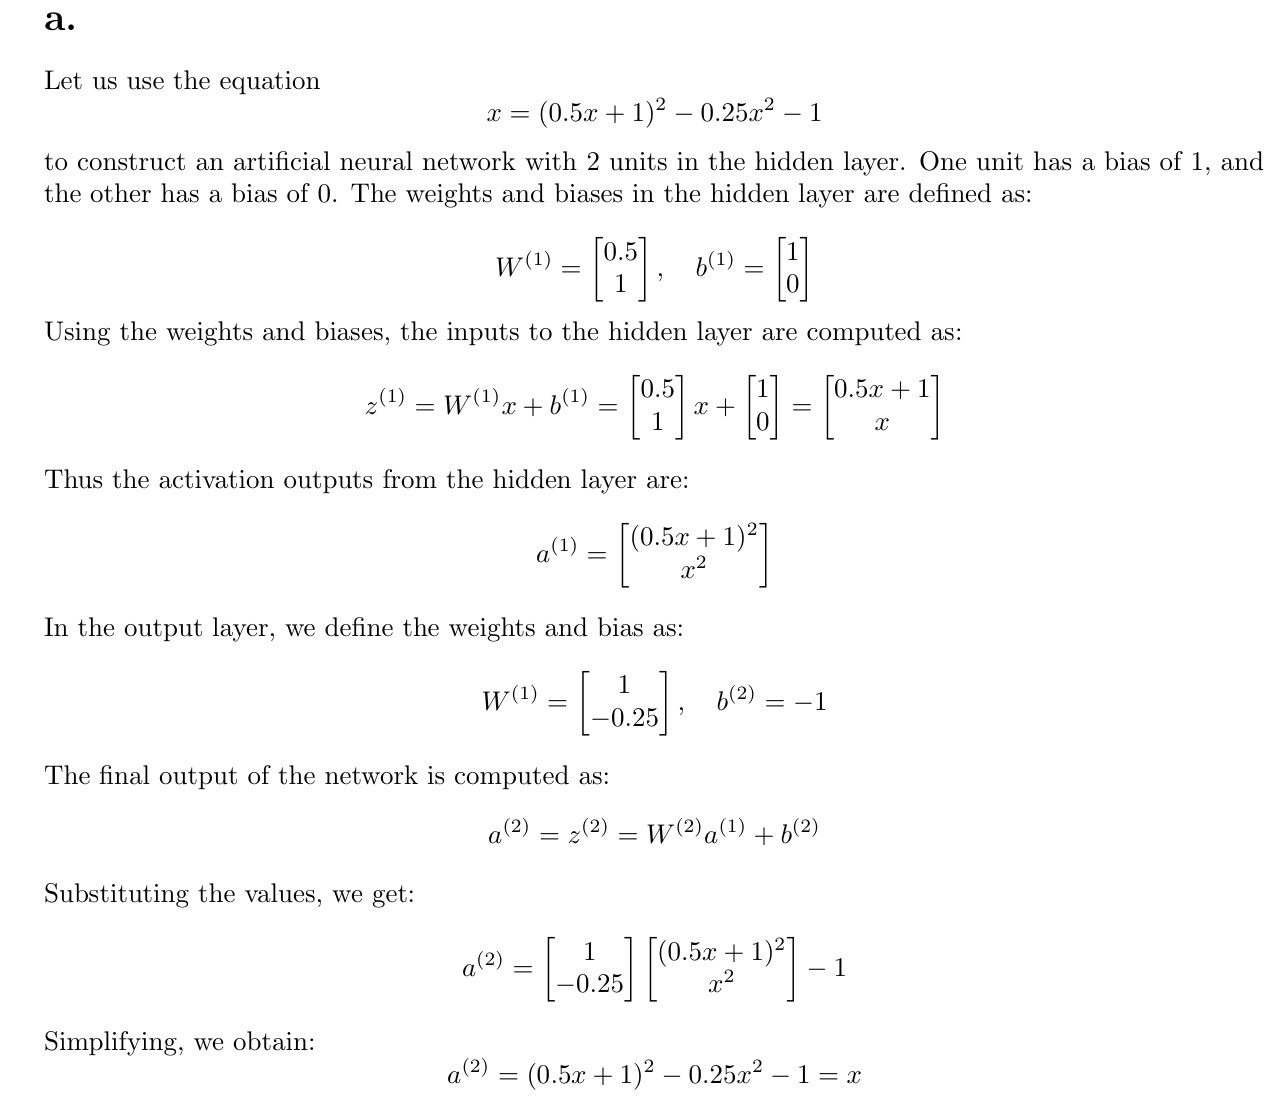

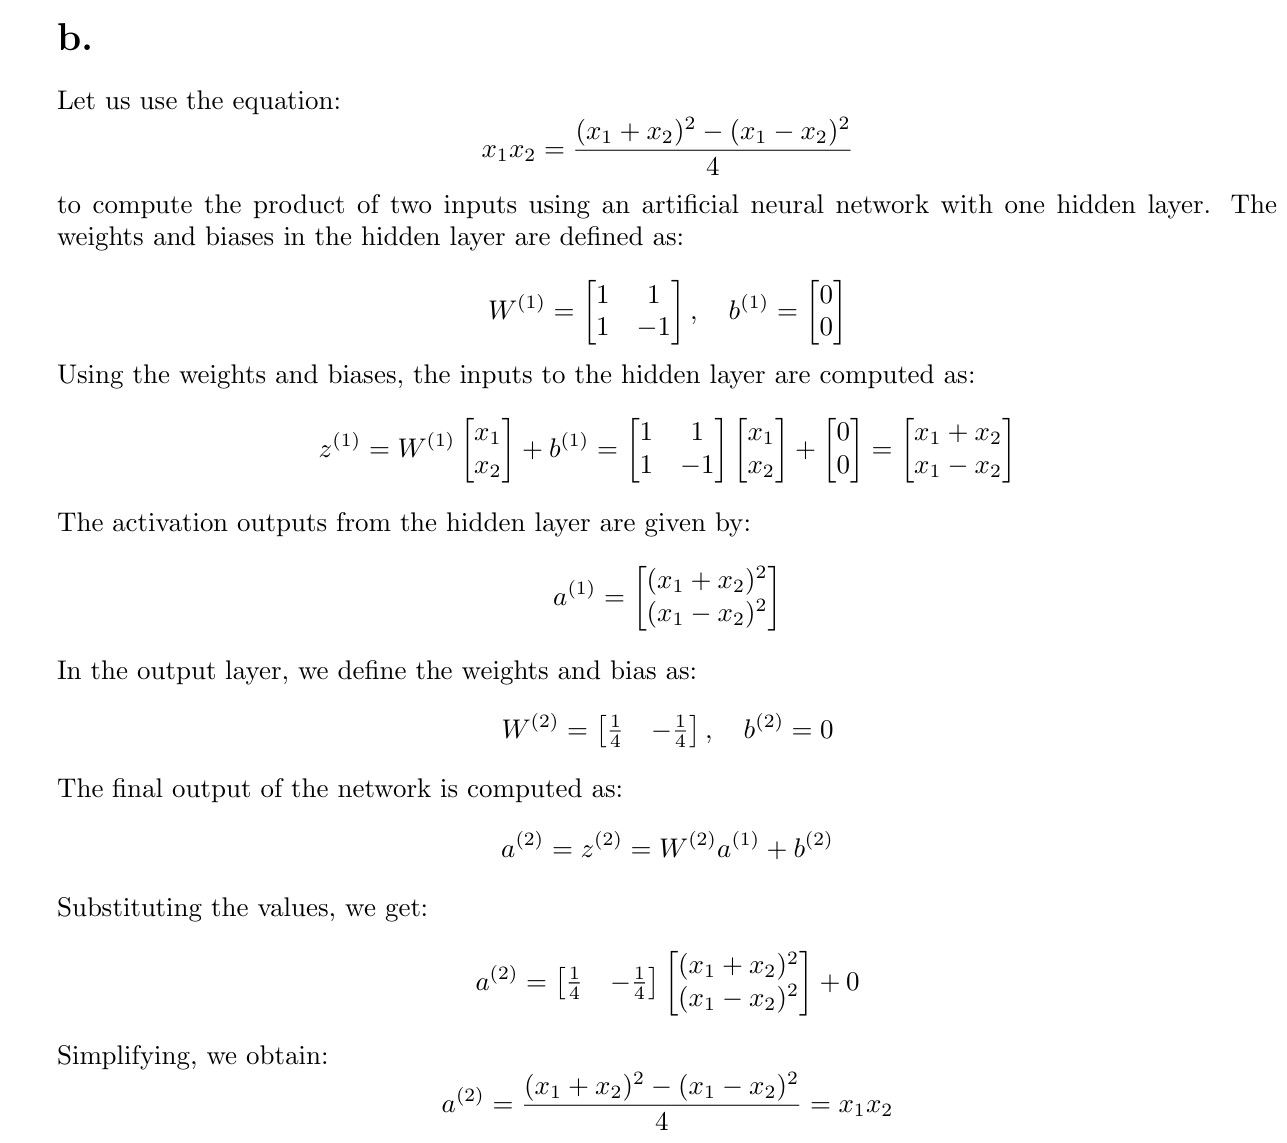

## Question 6

Suppose that we have a dataset for text classification of the following size:

* Number of training examples = 500000

* Vocabulary size = 40000

* Maximum lengh of a document = 5000

And we want to develop a deep learning model to do it. Let's say that our model will be based on 200-dimensional embeddings and 3 LSTM layers with 128 units in each layer.

Estimate the cost of fine-tuning the model (i.e., finding a good combination of training hyperparameters) and the cost of training such a model on the cloud.

When fine tuning the model, we have to find a good combination of training hyperparameters, such as hyperparameters relating to optimisation and regularisation and model architecture.  Suppose that there are 15 weight decay factors for L2 regularisation, and 15 various model architectures and 5 optimisers.  This means that there is a total of 1,125 models to test.  Given a training time of a model to be 5 minutes, it would take 94 hours to test all these models.  Given some leeway for human error, set up, we can assume that it would take 100 working hours to fine tune the model.

Knowing that we can have this process be done by an interns, entry level data scientists, or a data science company, we can consider the range of costs for this 100 hours of work.

Given that an entry level data scientist is paid \$6,950 on average per month, based on https://www.glassdoor.sg/Salaries/singapore-data-scientist-salary-SRCH_IL.0,9_IM1123_KO10,24.htm, and based on a 44 hour work week, it makes it that these 100 working hours would cost \$3,646 to fine tune this data.  This figure would be more if a data science company is doing the processing, or less should an intern be paid to do this task instead.


When training such a model on the cloud, training time would increase proportionately to training set size.  The current training set size of 10,000, and given a new training set size of 500,000.  We expect training time to increase by 50 times.

Also, the model that we are training is bigger than our current model, with more embedding layers and more LSTM units.  To also get a better fit model, we could train the model for more epochs than the current.  These increase in model size would also take more time to train the model.

Furthermore, TPUs that are used to train models on the cloud are known to be much faster than traditional GPUs that we have used on our laptops. (though NVIDIA GPUs may have faster speeds to train as compared to TPUs on the cloud, around twice as fast).

Given that it took a few minutes to train the above dataset on my laptop (4 minuites), we can estimate that the time to train this on the cloud would be
4 min x 50 times (larger dataset) x 10 times (larger model) x 1/12 (speedup from cloud) = 300 hours

This training on NVIDIA V100 would cost USD 744 or SGD 1,000.
According to this pricing https://cloud.google.com/compute/gpus-pricing?utm_source=google&utm_medium=cpc&utm_campaign=japac-SG-all-en-dr-SKWS-all-all-trial-DSA-dr-1605216&utm_content=text-ad-none-none-DEV_c-CRE_645025797249-ADGP_Hybrid+%7C+SKWS+-+BRO+%7C+DSA+-Compute-Compute+Engine-KWID_39700075148142379-dsa-1957356229609&userloc_9062504-network_g&utm_term=KW_&gad_source=1&gclid=EAIaIQobChMIp_ScupCqiwMVtimDAx05mDFjEAAYAiAAEgLd2fD_BwE&gclsrc=aw.ds.

## Question 7

Where in the financial industry can we make use of deep learning models for text classification? How can we estimate the net gain from implementing such models?

Applications of deep learning model in Finance could be:

1.Sentiment Analysis for Trading
Use Case: Classify news articles, earnings call transcripts, or social media posts to gauge market sentiment (like bullish/bearish) and generate trading signals.
Example: An LSTM model (like the one in Reuters example) could categorize news affecting specific stocks, commodities, or currencies.

2.Customer Service Automation
Use Case: Route customer inquiries (like complaints, loan requests) to appropriate departments using text classification.
Example: A model could categorize emails as "mortgage inquiry," "fraud alert," or "account closure request."

3.Risk Assessment
Use Case: Analyze credit reports, loan applications, or ESG disclosures to predict default risks or ESG compliance.
Example: Classify sections of annual reports into risk categories (like "high climate risk," "low liquidity risk").

the net gain could be estimated through calculating the cost saved, the gain created and the cost paid extraly:
1.Reduced manual labor can be calculated through the amount saved by using deep learning model instead of staff.

2.Revenue generation can exist if faster trade execution based on sentiment signals can produce potential alpha generation. Like a 0.5 percent improvement in trading strategy accuracy could yield millions annually for a fund.

3.Costs mostly depends on development costs, operational costs and data costs: The first includes cloud compute for training (like 2,000 dollars permonth for AWS GPU instances). Model tuning (engineer hours at 150 dollars per hour).
The second includes inference API costs (could be like 0.01 dollars per request for 1M requests). maintenance and updates (for paying like 50k dollars per year for a dedicated ML engineer).
The third includes purchasing labeling training data (like, paying 10k dollars for a labeled dataset of 100k documents).

After summing the costs and gains all above, we can generally get the net gain of implementing such model.